# End-to-End Render Deployment Project

## Problem Statement
Package an income classifier behind a small FastAPI service suitable for Render deployment.

## Dataset Description
The model-development notebook uses the UCI Adult dataset through OpenML; deployment files in this project are an explicit assignment exception.

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
from sklearn.datasets import fetch_openml
adult = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
data = adult.frame.dropna().copy(); data["target"] = data["class"].astype(str).str.contains(">50K").astype(int)

## Data Inspection & Cleaning

In [3]:
data = data.drop_duplicates(); print(data.shape); display(data.isna().sum().sort_values(ascending=False).head())

(45175, 16)


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

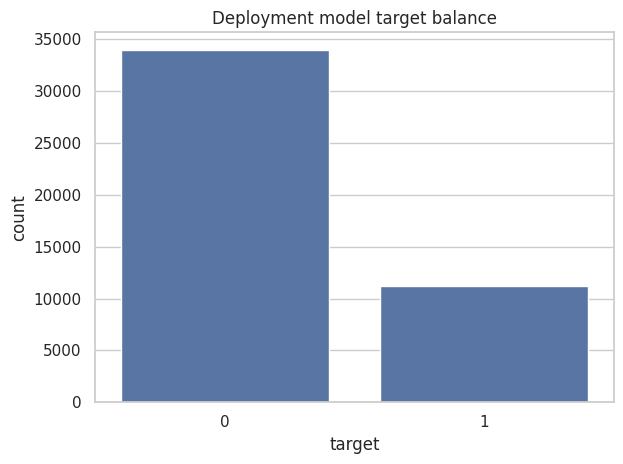

In [4]:
sns.countplot(data=data, x="target"); plt.title("Deployment model target balance"); plt.tight_layout()

## Feature Engineering

In [5]:
features = data.drop(columns=["class", "target"]); target = data.target

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, stratify=target, random_state=SEED)

## Model Development

In [7]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
import joblib
prep = make_column_transformer((make_pipeline(SimpleImputer(strategy="median")), features.select_dtypes("number").columns), (make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), features.select_dtypes(exclude="number").columns))
model = make_pipeline(prep, LogisticRegression(max_iter=500)); model.fit(X_train, y_train)
joblib.dump(model, Path("model.joblib"))
print("Exported model.joblib for the FastAPI service.")

Exported model.joblib for the FastAPI service.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Hyperparameter Tuning

In [8]:
# Tune C and the decision threshold on a validation set before deployment when the operational false-positive/false-negative costs are known.

## Evaluation

In [9]:
from sklearn.metrics import roc_auc_score
print("Held-out ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

Held-out ROC-AUC: 0.8818397728721551


## Visualizations

Text(0.5, 1.0, 'Deployment model ROC curve')

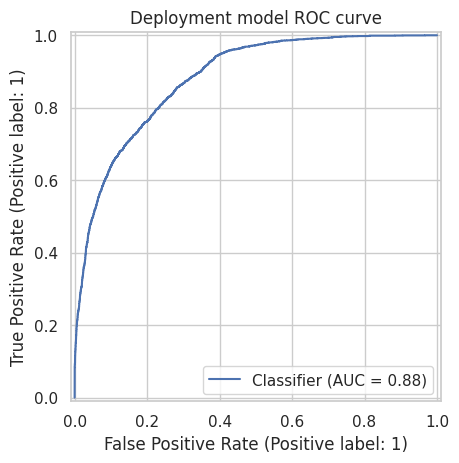

In [10]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, model.predict_proba(X_test)[:,1]); plt.title("Deployment model ROC curve")

## Prediction Examples

In [11]:
payload_example = X_test.iloc[[0]].to_dict(orient="records")[0]; print(payload_example); print(model.predict_proba(X_test.iloc[[0]])[:,1])

{'age': 37, 'workclass': 'Private', 'fnlwgt': 22245, 'education': 'Some-college', 'education-num': 10, 'marital-status': 'Divorced', 'occupation': 'Sales', 'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 40, 'native-country': 'Outlying-US(Guam-USVI-etc)'}
[0.11116]


## Discussion
The service validates request shape and loads a versioned serialized pipeline. Render configuration is included with this project as required by the assignment.

## Conclusion
The notebook trains and tests the same model artefact exposed by the accompanying API.